<a href="https://colab.research.google.com/github/yuriserede/Motor-de-Intelig-ncia-de-Varejo/blob/main/Motor_de_Intelig%C3%AAncia_de_Varejo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estrutura

motor_varejo/

main.py → ponto de entrada

data_manager.py → ingestão e proteção dos dados

models.py → classe abstrata ModeloAnalitico

churn_model.py → implementação concreta do modelo

exceptions.py → exceções personalizadas

In [34]:
from abc import ABC, abstractmethod

class ModeloAnalitico(ABC):

    @abstractmethod
    def treinar_modelo(self):
        pass

    @abstractmethod
    def gerar_predicao(self, dados):
        pass

In [35]:
from sklearn.tree import DecisionTreeClassifier

class ModeloChurn(ModeloAnalitico):

    def __init__(self):
        self._modelo = DecisionTreeClassifier()

    def treinar_modelo(self, X, y):
        self._modelo.fit(X, y)

    def gerar_predicao(self, dados):
        return self._modelo.predict(dados)

In [36]:
class DataManager:

    def __init__(self):
        self.__dataset = None

    def carregar_dataset(self, dataframe):
        self.__dataset = dataframe

    def obter_dataset(self):
        return self.__dataset.copy()

In [37]:
class DatasetException(Exception):
    pass


class ColunaObrigatoriaException(Exception):
    pass

In [38]:
class DataManager:

    def __init__(self):
        self.__dataset = None

    def carregar_dataset(self, dataframe):

        colunas_obrigatorias = [
            "idade",
            "valor_carrinho",
            "tempo_navegacao"
        ]

        for coluna in colunas_obrigatorias:

            if coluna not in dataframe.columns:
                raise ColunaObrigatoriaException(
                    f"Coluna ausente: {coluna}"
                )

        self.__dataset = dataframe

    def obter_dataset(self):
        return self.__dataset

In [39]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import rand, when, round

spark = SparkSession.builder \
    .appName("MotorInteligenciaVarejo") \
    .getOrCreate()

# Cria 1 milhão de registros
df = spark.range(1000000)

# Simula atributos dos clientes
df = df.withColumn(
    "idade",
    (rand() * 50 + 18).cast("integer")
)

df = df.withColumn(
    "tempo_navegacao",
    round(rand() * 120, 2)
)

df = df.withColumn(
    "valor_carrinho",
    round(rand() * 3000, 2)
)

df = df.withColumn(
    "quantidade_visitas",
    (rand() * 20).cast("integer")
)

# Variável alvo (abandono)
df = df.withColumn(
    "abandonou_carrinho",
    when(rand() > 0.65, 1).otherwise(0)
)

print("Quantidade de registros:")
print(df.count())

df.show(5)

Quantidade de registros:
1000000
+---+-----+---------------+--------------+------------------+------------------+
| id|idade|tempo_navegacao|valor_carrinho|quantidade_visitas|abandonou_carrinho|
+---+-----+---------------+--------------+------------------+------------------+
|  0|   37|          54.53|        2792.3|                16|                 0|
|  1|   61|          37.43|       2603.81|                 6|                 0|
|  2|   29|          84.61|        739.49|                16|                 0|
|  3|   39|          23.12|       2511.45|                 1|                 0|
|  4|   56|         101.68|        626.13|                 7|                 1|
+---+-----+---------------+--------------+------------------+------------------+
only showing top 5 rows


In [40]:
dados_consolidados = df.groupBy(
    "abandonou_carrinho"
).avg(
    "idade",
    "tempo_navegacao",
    "valor_carrinho"
)

dados_consolidados.show()

+------------------+-----------------+--------------------+-------------------+
|abandonou_carrinho|       avg(idade)|avg(tempo_navegacao)|avg(valor_carrinho)|
+------------------+-----------------+--------------------+-------------------+
|                 1|42.52335356709277|  59.996038905949746| 1498.4956522173702|
|                 0|42.48481440166173|   59.99471048197832| 1498.3102299342327|
+------------------+-----------------+--------------------+-------------------+



# Análise de Complexidade do Modelo de Árvore de Decisão

Para a etapa de previsão de abandono de carrinho foi utilizado o algoritmo Árvore de Decisão, amplamente empregado em problemas de classificação devido à sua interpretabilidade e simplicidade de implementação.

O treinamento da árvore consiste em avaliar diferentes divisões dos dados para encontrar aquela que produz a melhor separação entre as classes. Em cada nó da árvore, o algoritmo calcula métricas como Entropia ou Índice de Gini para determinar a melhor divisão possível.

Considerando um conjunto com n registros e m atributos, a complexidade média de treinamento é aproximadamente O(n log n), pois os dados são divididos recursivamente em subconjuntos menores até que os critérios de parada sejam atingidos. Em cenários desfavoráveis, quando a árvore cresce excessivamente e os dados são mal distribuídos, a complexidade pode se aproximar de O(n²).

A etapa de predição possui custo muito reduzido. Para cada nova observação, basta percorrer os nós da árvore até chegar a uma folha de decisão, resultando em uma complexidade aproximada de O(log n).

Em aplicações de comércio eletrônico, a Árvore de Decisão apresenta excelente relação entre desempenho e custo computacional, permitindo identificar clientes com alta probabilidade de abandonar o carrinho e possibilitando ações preventivas, como ofertas personalizadas, cupons de desconto e campanhas de remarketing.

Além disso, o modelo oferece transparência na interpretação dos resultados, permitindo compreender quais características dos usuários influenciam mais fortemente a decisão de compra ou abandono.


In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


class ModeloChurn(ModeloAnalitico):

    def __init__(self):
        self.modelo = DecisionTreeClassifier(
            criterion='gini',
            max_depth=5,
            random_state=42
        )

    def treinar_modelo(self, X, y):

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        self.modelo.fit(X_train, y_train)

        previsoes = self.modelo.predict(X_test)

        acuracia = accuracy_score(
            y_test,
            previsoes
        )

        print(f"Acurácia: {acuracia:.2%}")

    def gerar_predicao(self, dados):
        return self.modelo.predict(dados)

In [42]:
import re
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

class AnalisadorFeedback:

    @staticmethod
    def limpar_texto(texto):

        texto = texto.lower()

        texto = re.sub(r'[^a-zA-ZÀ-ÿ\s]', '', texto)

        stopwords = {
            'de', 'da', 'do', 'das', 'dos',
            'a', 'o', 'as', 'os',
            'e', 'é', 'foi', 'ser',
            'para', 'com', 'em', 'um',
            'uma', 'na', 'no'
        }

        palavras = texto.split()

        palavras_filtradas = [
            palavra
            for palavra in palavras
            if palavra not in stopwords
        ]

        return " ".join(palavras_filtradas)

    @staticmethod
    def extrair_termos_relevantes(comentarios):

        texto_total = ""

        for comentario in comentarios:
            texto_total += " " + \
                AnalisadorFeedback.limpar_texto(
                    comentario
                )

        frequencias = Counter(
            texto_total.split()
        )

        return frequencias.most_common(20)

    @staticmethod
    def gerar_wordcloud(comentarios):

        texto_total = ""

        for comentario in comentarios:
            texto_total += " " + \
                AnalisadorFeedback.limpar_texto(
                    comentario
                )

        nuvem = WordCloud(
            width=1200,
            height=600,
            background_color='white'
        ).generate(texto_total)

        plt.figure(figsize=(12, 6))
        plt.imshow(nuvem)
        plt.axis("off")

        plt.savefig(
            "outputs/wordcloud.png"
        )

        plt.show()

In [43]:
comentarios = [

    "Entrega rápida e produto excelente",

    "Produto chegou quebrado",

    "Atendimento excelente",

    "Demorou muito para entregar",

    "Ótimo custo benefício",

    "Produto veio com defeito",

    "Qualidade excelente",

    "Entrega atrasada",

    "Gostei muito da compra",

    "Produto excelente e entrega rápida"
]

In [44]:
termos = AnalisadorFeedback \
    .extrair_termos_relevantes(
        comentarios
    )

print(termos)

[('produto', 4), ('excelente', 4), ('entrega', 3), ('rápida', 2), ('muito', 2), ('chegou', 1), ('quebrado', 1), ('atendimento', 1), ('demorou', 1), ('entregar', 1), ('ótimo', 1), ('custo', 1), ('benefício', 1), ('veio', 1), ('defeito', 1), ('qualidade', 1), ('atrasada', 1), ('gostei', 1), ('compra', 1)]


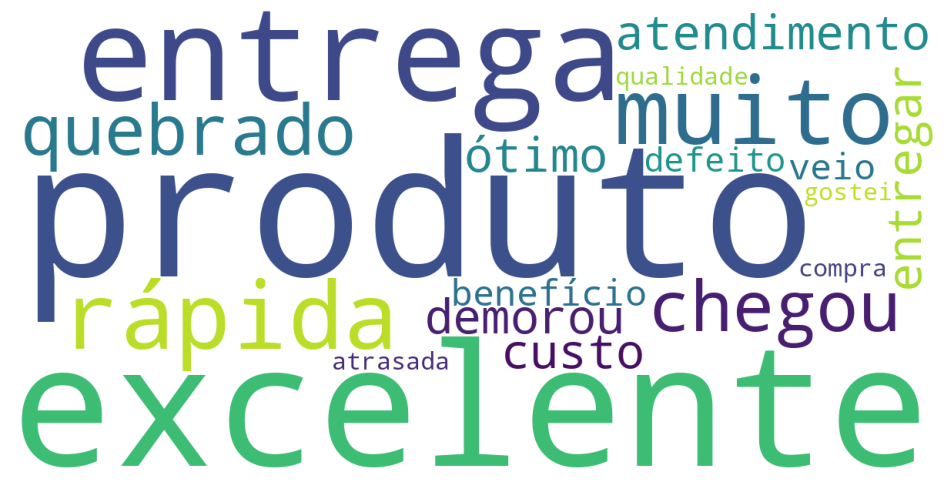

In [45]:
import os

os.makedirs('outputs', exist_ok=True)
AnalisadorFeedback.gerar_wordcloud(
    comentarios
)

In [46]:
import networkx as nx


class MotorRecomendacao:

    __grafo = nx.Graph()

    @staticmethod
    def adicionar_compra(produtos):

        for i in range(len(produtos)):

            for j in range(i + 1, len(produtos)):

                produto_a = produtos[i]
                produto_b = produtos[j]

                if MotorRecomendacao.__grafo.has_edge(
                    produto_a,
                    produto_b
                ):

                    MotorRecomendacao.__grafo[
                        produto_a
                    ][produto_b]["peso"] += 1

                else:

                    MotorRecomendacao.__grafo.add_edge(
                        produto_a,
                        produto_b,
                        peso=1
                    )

    @staticmethod
    def recomendar(produto, limite=3):

        if produto not in MotorRecomendacao.__grafo:

            return []

        vizinhos = []

        for vizinho in MotorRecomendacao.__grafo.neighbors(
            produto
        ):

            peso = MotorRecomendacao.__grafo[
                produto
            ][vizinho]["peso"]

            vizinhos.append(
                (vizinho, peso)
            )

        vizinhos.sort(
            key=lambda x: x[1],
            reverse=True
        )

        return vizinhos[:limite]

In [47]:
compras = [

    ["Notebook", "Mouse", "Teclado"],

    ["Notebook", "Headset"],

    ["Mouse", "Mousepad"],

    ["Notebook", "Mouse"],

    ["Teclado", "Mouse"],

    ["Notebook", "Mouse"],

    ["Notebook", "Mouse"]
]

for compra in compras:

    MotorRecomendacao.adicionar_compra(
        compra
    )

In [48]:
recomendacoes = \
    MotorRecomendacao.recomendar(
        "Notebook"
    )

print(recomendacoes)

[('Mouse', 4), ('Teclado', 1), ('Headset', 1)]


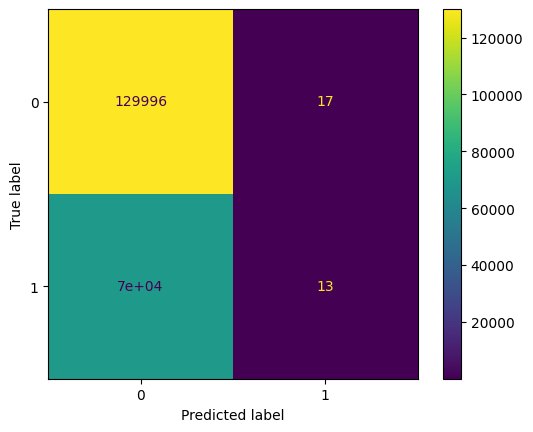

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

os.makedirs('outputs', exist_ok=True)

feature_columns = ["idade", "tempo_navegacao", "valor_carrinho", "quantidade_visitas"]
target_column = "abandonou_carrinho"

pandas_df = df.select(feature_columns + [target_column]).toPandas()

X = pandas_df[feature_columns]
y = pandas_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

previsoes = model.predict(X_test)

matriz = confusion_matrix(
    y_test,
    previsoes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz
)

disp.plot()

plt.savefig(
    "outputs/matriz_confusao.png"
)

plt.show()